In [ ]:
# import glob
# import polars as pl


# df_lst = []

# for file in glob.glob("bioproject_metadata/*csv"):
#     df = (
#         pl.read_csv(file)
#             .rename({
#                 "Run": "acc",
#                 "BioSample": "biosample",
#                 "BioProject": "bioproject"
#             })
#             .with_columns([
#                 (pl.col('biosample') + "_" + pl.col("acc") + "_cf").alias('sample'),
#                 pl.col('acc').alias('group'),
#                 pl.lit(None).alias('fastq_1'),
#                 pl.lit(None).alias('fastq_2'),
#             ])
#     )

#     if file.endswith('PRJEB32062.csv'):
#         df = (
#             df
#             .with_columns([
#                 pl.col('host_subject_id').alias('coassembly_group'),
#                 pl.col('Collection_Date').alias('timepoint'),
#                 pl.col('environment_(material)').alias('sample_type'),
#                 pl.col('miscellaneous_parameter').alias('condition')
#             ])
#     )

#     if file.endswith('PRJEB51171.csv'):
#         df = (
#             df
#             .with_columns([
#                 pl.col('Sample_name').str.split('_V').list[0].alias('coassembly_group'),
#                 pl.col('Sample_name').str.split('_').list[2].alias('timepoint'),
#                 pl.col('Sample_name').str.split('_').list[3].alias('sample_type'),
#                 pl.when(pl.col('Sample_name').str.contains('V1')).then(pl.lit('Pre ETI'))
#                     .otherwise(pl.lit('On ETI')).alias('condition')
#             ])
#     )
        
#     if file.endswith('PRJNA516870.csv'):
#         df = (
#             df
#             .with_columns([
#                 pl.col('Sample Name').str.split('_').list[1].alias('coassembly_group'),
#                 pl.col('Collection_Date').alias('timepoint'),
#                 pl.col('env_medium').alias('sample_type'),
#                 pl.col('exacerbation_status').alias('condition')
#             ])
#     )
        
#     if file.endswith('PRJNA530252.csv'):
#         df = (
#             df
#             .with_columns([
#                 pl.col('Sample Name').str.split('S').list[0].alias('coassembly_group'),
#                 pl.col('Sample Name').str.split('S').list[1].alias('timepoint'),
#                 pl.lit('sputum').alias('sample_type'),
#                 pl.when(pl.col('Sample Name').str.contains('S0')).then(pl.lit('Pre TIP'))
#                     .when(pl.col('Sample Name').str.contains('S5')).then(pl.lit('Post TIP'))
#                     .otherwise(pl.lit('On TIP')).alias('condition')
#             ])
#     )
        
#     if file.endswith('PRJNA825831.csv'):
#         df = (
#             df
#             .with_columns([
#                 pl.col('source_material_id').str.split(' ').list[0].alias('coassembly_group'),
#                 pl.col('source_material_id').str.split(' ').list[-1].alias('timepoint'),
#                 pl.col('isolation_source').alias('sample_type'),
#                 pl.col('source_material_id').str.split(' ').list[1].alias('condition')
#             ])
#     )
        
#     if file.endswith('PRJNA846291.csv'):
#         df = (
#             df
#             .with_columns([
#                 pl.col('Sample Name').str.split('E').list[0].alias('coassembly_group'),
#                 pl.col('Sample Name').str.split('E').list[1].alias('timepoint'),
#                 pl.col('isolation_source').alias('sample_type'),
#                 pl.when(pl.col('source_material_id').str.ends_with('S')).then(pl.lit('sick'))
#                     .when(pl.col('source_material_id').str.ends_with('W')).then(pl.lit('well'))
#                     .otherwise(pl.lit('hospital')).alias('condition')
#             ])
#     )

#     if file.endswith('PRJNA931830.csv'):
#         df = (
#             df
#             .with_columns([
#                 pl.col('Patient_ID').alias('coassembly_group'),
#                 pl.col('Collection_Date').alias('timepoint'),
#                 pl.col('isolation_source').alias('sample_type'),
#                 pl.lit('Unknown').alias('condition')
#             ])
#     )
        
#     if file.endswith('PRJNA1091195.csv'):
#         df = (
#             df
#             .filter(pl.col('Platform') == 'ILLUMINA')
#             .with_columns([
#                 pl.col('Sample Name').str.split('-').list[0].alias('coassembly_group'),
#                 pl.col('Collection_Date').alias('timepoint'),
#                 pl.col('isolation_source').alias('sample_type'),
#                 pl.lit('IV Abx').alias('condition')
#             ])
#     )
        
#     if file.endswith('PRJNA1101448.csv'):
#         df = (
#             df
#             .with_columns([
#                 pl.col('Sample Name').str.replace(r'\d+$', '').alias('coassembly_group'),
#                 pl.col('Collection_Date').alias('timepoint'),
#                 pl.col('isolation_source').alias('sample_type'),
#                 pl.lit('ETI').alias('condition')
#             ])
#     )

#     df_lst.append(df[['sample', 'bioproject', 'group', 'biosample', 'acc', 'fastq_1', 'fastq_2', 'coassembly_group', 'timepoint', 'sample_type', 'condition']])

# final_df = pl.concat(df_lst, how='vertical_relaxed')

In [ ]:
# final_df.write_csv('cf_longitudinal_samplesheet2.csv')

In [6]:
import polars as pl

samplesheet = pl.read_csv('cf_longitudinal_samplesheet.csv')
multi_samp = set(
    samplesheet
        .group_by(['bioproject', 'coassembly_group'])
        .len()
        .sort('len', descending=True)
        .filter(pl.col('len') > 1)
        ['coassembly_group']
)

samplesheet.filter(pl.col('coassembly_group').is_in(multi_samp))

sample,bioproject,group,biosample,acc,fastq_1,fastq_2,coassembly_group,timepoint,sample_type,condition
str,str,str,str,str,str,str,str,str,str,str
"""SAMEA5554290_ERR3274613_cf""","""PRJEB32062""","""ERR3274613""","""SAMEA5554290""","""ERR3274613""",null,null,"""6""","""2015-02-04""","""sputum""","""no exacerbation"""
"""SAMEA5554291_ERR3274614_cf""","""PRJEB32062""","""ERR3274614""","""SAMEA5554291""","""ERR3274614""",null,null,"""6""","""2015-06-19""","""sputum""","""exacerbation"""
"""SAMEA5554292_ERR3274615_cf""","""PRJEB32062""","""ERR3274615""","""SAMEA5554292""","""ERR3274615""",null,null,"""6""","""2015-07-13""","""sputum""","""no exacerbation"""
"""SAMEA5554293_ERR3274616_cf""","""PRJEB32062""","""ERR3274616""","""SAMEA5554293""","""ERR3274616""",null,null,"""6""","""2015-08-26""","""sputum""","""exacerbation"""
"""SAMEA5554294_ERR3274617_cf""","""PRJEB32062""","""ERR3274617""","""SAMEA5554294""","""ERR3274617""",null,null,"""6""","""2015-10-19""","""sputum""","""exacerbation"""
…,…,…,…,…,…,…,…,…,…,…
"""L13211""","""lipuma_aim2""","""L13211""","""L13211""",null,"""/mmfs1/gscratch/pedslabs_hoffm…","""/mmfs1/gscratch/pedslabs_hoffm…","""L13""",null,null,null
"""L13242""","""lipuma_aim2""","""L13242""","""L13242""",null,"""/mmfs1/gscratch/pedslabs_hoffm…","""/mmfs1/gscratch/pedslabs_hoffm…","""L13""",null,null,null
"""L13272""","""lipuma_aim2""","""L13272""","""L13272""",null,"""/mmfs1/gscratch/pedslabs_hoffm…","""/mmfs1/gscratch/pedslabs_hoffm…","""L13""",null,null,null


In [7]:
len(multi_samp)

154

In [1]:
### load sylph data
import glob
import os
import polars as pl
from polars.exceptions import NoDataError

sylph_lst = []

for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/analyze/lipuma_aim2/*/*/sylph/profile/*.profile.tsv'):
    # check if sylph results exist
    if not os.path.isfile(f'{file}'):
        continue
    # get sample name
    sample_name = file.split('/')[-4]
    bioproject = file.split('/')[-6]
    # # parse log to count number of bp after deacon
    # with open(f'{file.split('/sylph/profile/')[0].replace('analyze', 'assemble')}/readpreprocessing/.command.log', 'r') as log:
    #     for line in log:
    #         if line.startswith('Retained '):
    #             num_bp = int(line.split()[4].split('/')[0])

    # parse sylph results to count number of genomes, bac, and viruses per bp
    try:
        df = pl.read_csv(file, separator='\t', ignore_errors=True)

        if df.height == 0:
            raise NoDataError

        sylph_lst.append(
            df.with_columns([
                # pl.lit(num_bp).cast(pl.Int64).alias('num_bp'),
                pl.lit(sample_name).alias('sample_id'),
                pl.lit(bioproject).alias('bioproject'),
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ])
            [['sample_id', 'bioproject', 'contig_id', 'Genome_file', 'Taxonomic_abundance', 'Sequence_abundance', 'Adjusted_ANI', 'True_cov']]
        )
    except NoDataError:
        df = pl.DataFrame(
            {
                # 'num_bp': [num_bp],
                'sample_id': [sample_name],
                'bioproject': [bioproject],
                'contig_id': [None],
                'Genome_file': [None],
                'Taxonomic_abundance': [0.0],
                'Sequence_abundance': [0.0],
                'Adjusted_ANI': [0.0],
                'True_cov': [0.0]
            }
        )

        sylph_lst.append(df)

sylph_df = pl.concat(sylph_lst)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [2]:
import glob
import os
import math
import polars as pl
from polars.exceptions import NoDataError

coverm_lst = []

for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/analyze/lipuma_aim2/*/*/coverm/contig/*.coverm.tsv'):
    # check if sylph results exist
    if not os.path.isfile(f'{file}'):
        continue
    # get sample name
    sample_name = file.split('/')[-4]
    bioproject = file.split('/')[-6]

    # parse coverm results to count number of genomes, bac, and viruses per bp
    try:
        df = (
            pl.read_csv(file,
                separator='\t', ignore_errors=True, new_columns=['contig_id', 'trimmed_mean', 'variance', 'mean', 'covered_bases', 'length'])
                .with_columns([
                    (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                ])
                .with_columns([
                    (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                ])
                .with_columns([
                    (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
                ])
                [['contig_id', 'trimmed_mean', 'mean', 'breadth', 'breadth_ratio']]
        )

        if df.height == 0:
            raise NoDataError

        coverm_lst.append(
            df.with_columns([
                # pl.lit(num_bp).cast(pl.Int64).alias('num_bp'),
                pl.lit(sample_name).alias('sample_id'),
                pl.lit(bioproject).alias('bioproject')
            ])
            [['sample_id', 'bioproject', 'contig_id', 'trimmed_mean', 'mean', 'breadth', 'breadth_ratio']]
        )
    except NoDataError:
        df = pl.DataFrame(
            {
                # 'num_bp': [num_bp],
                'sample_id': [sample_name],
                'bioproject': [bioproject],
                'contig_id': [None],
                'trimmed_mean': [0.0],
                'mean': [0.0],
                'breadth': [0.0],
                'breadth_ratio': [0.0]
            }
        )

        coverm_lst.append(df)

coverm_df = pl.concat(coverm_lst, how='vertical_relaxed')

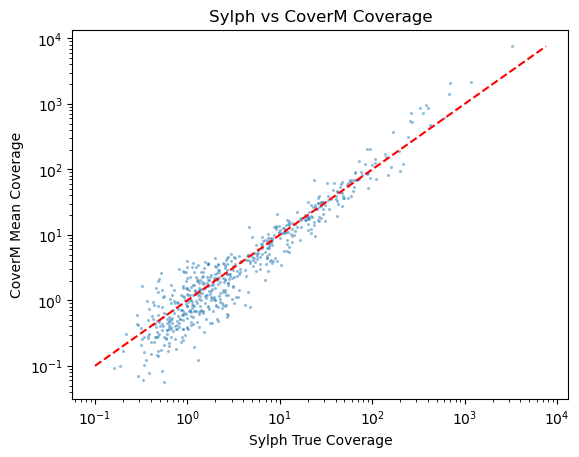

In [3]:
# plot sylph vs coverm coverage
sylph_w_coverm = (
    sylph_df
        .join(
            coverm_df,
            on=['sample_id', 'contig_id', 'bioproject'],
            how='inner'
        )
)
import seaborn as sns
import matplotlib.pyplot as plt
# prepare data for plotting
sns.scatterplot(data=sylph_w_coverm, x='True_cov', y='trimmed_mean', s=5, alpha=0.5)
plt.yscale('log')
plt.xscale('log')
# plot diagonal
max_cov = max(sylph_w_coverm['True_cov'].max(), sylph_w_coverm['trimmed_mean'].max())
plt.plot([0.1, max_cov], [0.1, max_cov], color='red', linestyle='--')
plt.xlabel('Sylph True Coverage')
plt.ylabel('CoverM Mean Coverage')
plt.title('Sylph vs CoverM Coverage')
plt.show()

In [ ]:
%%bash
# echo "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_10/uhvdb_votu_reps.fna.gz" > ref_kdb.txt

# # build kmer-db database for reference
# kmer-db \
#     build \
#     -k 25 \
#     -f 0.2 \
#     -t 32 \
#     -multisample-fasta \
#     ref_kdb.txt \
#     ref.kdb

# cat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/mine/lipuma_aim2/*/*/uhvdb/virusfilter/*.uhvdb_viruses.fna.gz \
#     > lipuma_aim2_viruses.fna.gz

# echo "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_7/lipuma_aim2_viruses.fna.gz" > query_kdb.txt

# # compare query to reference
# kmer-db \
#     new2all \
#     -sparse \
#     -min num-kmers:20 \
#     -min ani-shorter:0.0 \
#     -t 24 \
#     -multisample-fasta \
#     ../figure_6/ref.kdb \
#     query_kdb.txt \
#     query_v_ref.csv

# # convert kmer-db output to LZ-ANI filter format
# kmer-db \
#     distance \
#     ani-shorter \
#     -sparse \
#     -min 0.0 \
#     -t 24 \
#     query_v_ref.csv \
#     query_v_ref.dist.csv

# /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb/bin/kmerdb_new2all_to_lzani.py \
#     -i query_v_ref.dist.csv \
#     -o lipuma_aim2_v_uhvdb_r2025_10.vclust_prefilter.txt

# zcat "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_10/uhvdb_votu_reps.fna.gz" > lipuma_aim2_v_uhvdb_r2025_10.ref_query_combined.fna
# zcat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_7/lipuma_aim2_viruses.fna.gz >> lipuma_aim2_v_uhvdb_r2025_10.ref_query_combined.fna

# # align sequences with LZ-ANI
# lz-ani \
#     all2all \
#     --in-fasta lipuma_aim2_v_uhvdb_r2025_10.ref_query_combined.fna \
#     -o lipuma_aim2_v_uhvdb_r2025_10.vclust_ani.tsv \
#     --out-format query,reference,gani,tani,ani,qcov,rcov \
#     -t 24 \
#     --multisample-fasta true \
#     --out-type tsv \
#     --out-filter ani 0.0 \
#     --flt-kmerdb lipuma_aim2_v_uhvdb_r2025_10.vclust_prefilter.txt 0.0

# gzip lipuma_aim2_v_uhvdb_r2025_10.ref_query_combined.fna

In [4]:
# load unenriched vs uhvdb blast results
lipuma_viruses_v_uhvdb = (
    pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_7/lipuma_aim2_v_uhvdb_r2025_10.vclust_ani.tsv', separator='\t')
        .with_columns([
            pl.col('query').str.split('_k').list[0].alias('sample_id')
        ])
        .sort('gani', descending=True)
        .group_by('query', maintain_order=True)
        .head(1)
)

In [ ]:
# load bacphlip results for UHVDB
bacphlip_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/uhvdb_*_chunks/*.fna.bacphlip'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], new_columns=['contig_id', 'virulent', 'temperate'])
    )
    bacphlip_lst.append(df)

bacphlip_df = (
    pl.concat(bacphlip_lst)
        .with_columns([
            pl.when(pl.col('contig_id').str.contains('provirus')).then(pl.lit(0.0)).otherwise(pl.col('virulent')).alias('virulent')
        ])
)

# load uhvdb votu info
uhvdb_info = (
    pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_cf_supplement/r2025_10_uhvdb_vclust_votu_cluster_info_final.tsv', separator='\t')
        .filter(pl.col('contig_id') == pl.col('votu_rep'))
        .unique('votu_rep')
)

# load checkv results for cf viruses
checkv_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/mine/lipuma_aim2/*/*/checkv/*quality_summary.tsv.gz'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'])
            [['contig_id', 'provirus', 'completeness', 'host_genes', 'viral_genes', 'completeness_method']]
    )
    checkv_lst.append(df)

checkv_df = (
    pl.concat(checkv_lst, how='vertical_relaxed')
)

# # identify mvirs active cf viruses
# !cat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/analyze/lipuma_aim2/*/*/strobealign/*.mvirs.fasta | \
#     grep "^>" > lipuma_mvirs_contig_ids.txt

# mvirs_contigs = (
#     pl.read_csv('lipuma_mvirs_contig_ids.txt', separator=' ', has_header=False, new_columns=['mvirs_id'])
#         .with_columns([
#             pl.col('mvirs_id').str.replace('>', '').str.split(':').list[0].alias('contig_id_no_prophage'),
#             pl.col('mvirs_id').str.split('OPRs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_oprs'),
#             pl.col('mvirs_id').str.split('HSs=').list[1].str.split('-').list[0].cast(pl.Int64).alias('num_clipped'),
#         ])
#         .with_columns([
#             pl.col('contig_id_no_prophage').str.split('_k').list[0].alias('sample_id')
#         ])
# )


# load propagate results for cf viruses
propagate_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/analyze/lipuma_aim2/*/*/propagate/*.propagate.tsv'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], raise_if_empty=False)
    )
    if df.height > 0:
        df = (
            df
            .with_columns([
                    pl.col('prophage').cast(pl.String),
                    pl.col('host').cast(pl.String),
                    pl.col('prophage_len').cast(pl.Int64),
                    pl.col('CohenD').cast(pl.Float64),
                    pl.col('prophage-host_ratio').cast(pl.Float64),
                    pl.col('prophage').str.split('_k').list[0].alias('sample_id')
                ])
            [['prophage', 'prophage_len', 'host', 'CohenD', 'prophage-host_ratio', 'sample_id']]
        )
        propagate_lst.append(df)
    else:
        continue

propagate_df = (
    pl.concat(propagate_lst)
)


# load qpcr data for phix
qpcr_data = pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_7/lipuma_aim2_phix_recovery.tsv', separator='\t')

# combine all data together
activity_data = (
    sylph_w_coverm
        .join(uhvdb_info, on='contig_id', how='left')
        .join(bacphlip_df, on='contig_id', how='left')
        .join(lipuma_viruses_v_uhvdb, left_on=['contig_id', 'sample_id'], right_on=['reference', 'sample_id'], how='left')
        .with_columns([
            pl.col('query').str.split('|provirus').list[0].alias('contig_id_no_prophage')
        ])
        .join(propagate_df, left_on=['query', 'sample_id'], right_on=['prophage', 'sample_id'], how='left')
        .join(checkv_df, left_on='query', right_on='contig_id', how='left')
        # .join(mvirs_contigs, on=['contig_id_no_prophage', 'sample_id'], how='left')
        .with_columns([
            # breadth of coverage as an indicator that a virus is not fragmented
            pl.when((pl.col('breadth') >= 0.8) | (pl.col('breadth_ratio') >= 0.9)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('breadth_score'),
            # reference evidence of activity
            pl.when(pl.col('completeness_method').str.contains('DTR')).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_dtr_score'),
            pl.when((pl.col('virulent') >= 0.95)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_virulent_score'),
            # complete genome activity evidence
            pl.when((pl.col('completeness_method_right').str.contains('TR'))).then(pl.lit(3.0))
                .otherwise(pl.lit(0.0)).alias('dtr_score'),
            # pl.when((pl.col('num_oprs') + pl.col('num_clipped')) >= 5).then(pl.lit(3.0))
            #     .otherwise(pl.lit(0.0)).alias('mvirs_score'),
            # fragment evidence of activity
            pl.when((pl.col('CohenD') >= 1.5)).then(pl.lit(3.0))
                .when((pl.col('CohenD') >= 0.7)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('propagate_score'),
        ])
        .group_by(['contig_id', 'query', 'sample_id', 'bioproject'])
        .agg([
            pl.col('Taxonomic_abundance').first().alias('Taxonomic_abundance'),
            pl.col('True_cov').first().alias('True_cov'),
            pl.col('breadth_score').max().alias('breadth_score'),
            pl.col('ref_dtr_score').max().alias('ref_dtr_score'),
            pl.col('ref_virulent_score').max().alias('ref_virulent_score'),
            pl.col('trimmed_mean').first().alias('trimmed_mean'),
            pl.col('mean').first().alias('mean'),
            pl.col('breadth').first().alias('breadth'),
            pl.col('breadth_ratio').first().alias('breadth_ratio'),
            pl.col('completeness_method').first().alias('completeness_method'),
            pl.col('virulent').first().alias('virulent'),
            pl.col('dtr_score').max().alias('dtr_score'),
            # pl.col('num_oprs').max().alias('num_oprs'),
            # pl.col('num_clipped').max().alias('num_clipped'),
            pl.col('CohenD').max().alias('CohenD'),
            pl.col('prophage-host_ratio').max().alias('prophage-host_ratio'),
            # pl.col('mvirs_score').max().alias('mvirs_score'),
            pl.col('propagate_score').max().alias('propagate_score'),
        ])
        .with_columns([
            (
                pl.col('breadth_score') +
                pl.col('ref_dtr_score') +
                pl.col('ref_virulent_score') +
                pl.col('dtr_score') +
                # pl.col('mvirs_score') +
                pl.col('propagate_score')
            ).alias('activity_score')
        ])
        .with_columns([
            (
                pl.col('breadth_score') +
                pl.col('ref_dtr_score') +
                pl.col('ref_virulent_score')
            ).alias('reference_activity_score')
        ])
        .join(qpcr_data, on='sample_id', how='left')
)

In [15]:
all_viruses_set = set(
    activity_data
        .with_columns([
            pl.col('sample_id').str.slice(0, 3).alias('group')
        ])
        .group_by(['group', 'contig_id'])
        .agg([
            pl.col('activity_score').max(),
        ])
        .filter(pl.col('activity_score') >= 0)
        .with_columns([
            (pl.col('group') + "_" + pl.col('contig_id')).alias('group_contig')
        ])
        ['group_contig']
)

put_active_viruses_set = set(
    activity_data
        .with_columns([
            pl.col('sample_id').str.slice(0, 3).alias('group')
        ])
        .group_by(['group', 'contig_id'])
        .agg([
            pl.col('activity_score').max(),
        ])
        .filter(pl.col('activity_score') > 0)
        .with_columns([
            (pl.col('group') + "_" + pl.col('contig_id')).alias('group_contig')
        ])
        ['group_contig']
)

active_viruses_set = set(
    activity_data
        .with_columns([
            pl.col('sample_id').str.slice(0, 3).alias('group')
        ])
        .group_by(['group', 'contig_id'])
        .agg([
            pl.col('activity_score').max(),
        ])
        .filter(pl.col('activity_score') > 2)
        .with_columns([
            (pl.col('group') + "_" + pl.col('contig_id')).alias('group_contig')
        ])
        ['group_contig']
)

bac_set = set(
    sylph_df
        .with_columns([
            pl.col('sample_id').str.slice(0, 3).alias('group')
        ])
        .filter(pl.col('Genome_file').str.contains('R226CHUNK'))
        .with_columns([
            (pl.col('group') + "_" + pl.col('contig_id')).alias('group_contig')
        ])
        ['group_contig']
)

In [93]:
phix_ge = (
    activity_data
        .filter((pl.col('contig_id') == 'SAMN26351618.contig00026') & (~pl.col('sample_id').str.contains('coassembly')))
        .sort(pl.col('trimmed_mean'))
        .rename({
            'trimmed_mean': 'phix_trimmed_mean',
            'True_cov': 'phix_True_cov'
        })
        .with_columns([(pl.col('ge_per_250mg')/0.25).alias('ge_per_g')])
        [['sample_id', 'phix_True_cov', 'phix_trimmed_mean', 'ge_per_g']]
)

day_start = (
    activity_data
        .filter(~pl.col('sample_id').str.contains('coassembly'))
        .with_columns([
            pl.col('sample_id').str.slice(0, 3).alias('group'),
            pl.col('sample_id').str.slice(3, 7).cast(pl.Int64).alias('day')
        ])
        .group_by('group')
        .agg([pl.col('day').min().alias('day_start')])
        [['group', 'day_start']]
)


activity_data_plot = (
    activity_data
        .filter(~pl.col('sample_id').str.contains('coassembly'))
        .with_columns([
            pl.col('sample_id').str.slice(0, 3).alias('group'),
            pl.col('sample_id').str.slice(3, 7).cast(pl.Int64).alias('day')
        ])
        .join(phix_ge, on='sample_id', how='left')
        .with_columns([
            ((pl.col('trimmed_mean') / pl.col('phix_trimmed_mean')) * (pl.col('ge_per_g'))).alias('absolute_abundance')
        ])
        .join(day_start, on='group', how='left')
        .with_columns([
            (pl.col('day') - pl.col('day_start')).alias('day')
        ])
)

all_viruses = (
    activity_data_plot
        .filter(
            (pl.col('group') + "_" + pl.col('contig_id')).is_in(all_viruses_set)
        )
)

put_viruses = (
    activity_data_plot
        .filter(
            (pl.col('group') + "_" + pl.col('contig_id')).is_in(put_active_viruses_set)
        )
)

active_viruses = (
    activity_data_plot
        .filter(
            (pl.col('group') + "_" + pl.col('contig_id')).is_in(active_viruses_set)
        )
)

bac = (
    sylph_df
        .filter(~pl.col('sample_id').str.contains('coassembly'))
        .with_columns([
            pl.col('sample_id').str.slice(0, 3).alias('group'),
            pl.col('sample_id').str.slice(3, 7).cast(pl.Int64).alias('day')
        ])
        .filter(
            (pl.col('group') + "_" + pl.col('contig_id')).is_in(bac_set)
        )
)

/tmp/ipykernel_2153/857913828.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


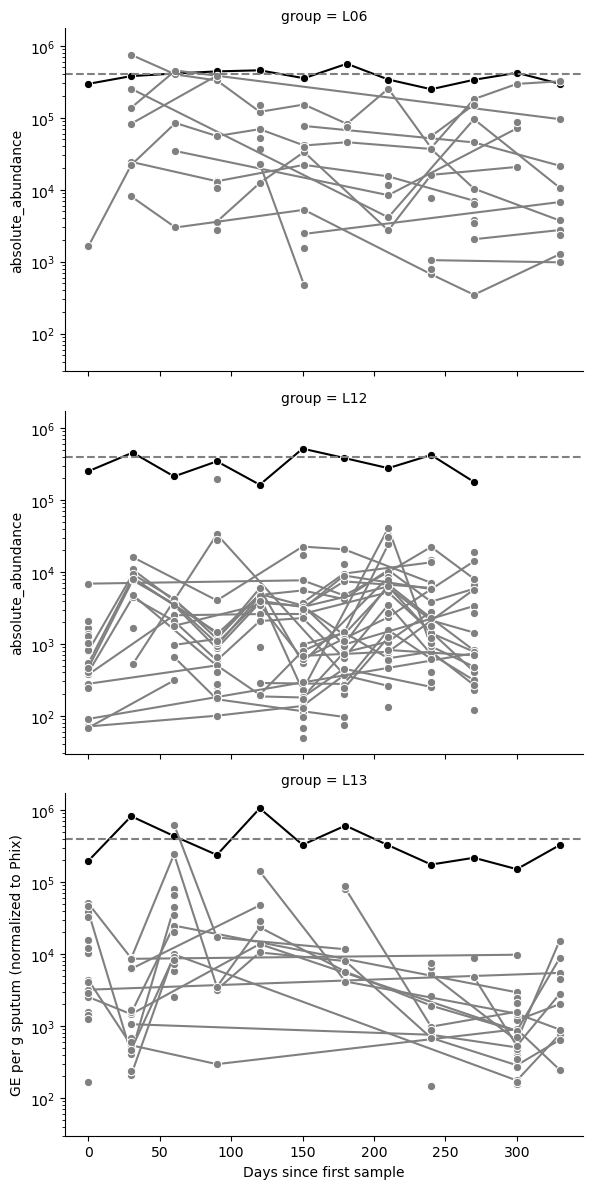

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
# prepare data for plotting
all_viruses = all_viruses.sort('group', descending=False)
g = sns.FacetGrid(all_viruses, row='group', height=4, aspect=1.5)

custom_palette = {}
for contig_id in all_viruses['contig_id'].unique().to_list():
    if contig_id == 'SAMN26351618.contig00026':
        custom_palette[contig_id] = 'black'
    else:
        custom_palette[contig_id] = 'grey'


g.map_dataframe(sns.lineplot, x='day', y='absolute_abundance', hue='contig_id', palette=custom_palette, marker='o', legend=False)
g.map(lambda *args, **kwargs: plt.axhline(y=4E5, color="grey", linestyle="--"))

plt.yscale('log')
plt.ylabel('GE per g sputum (normalized to Phix)')
plt.xlabel('Days since first sample')
plt.legend().remove()
plt.show()

/tmp/ipykernel_2153/1779407767.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


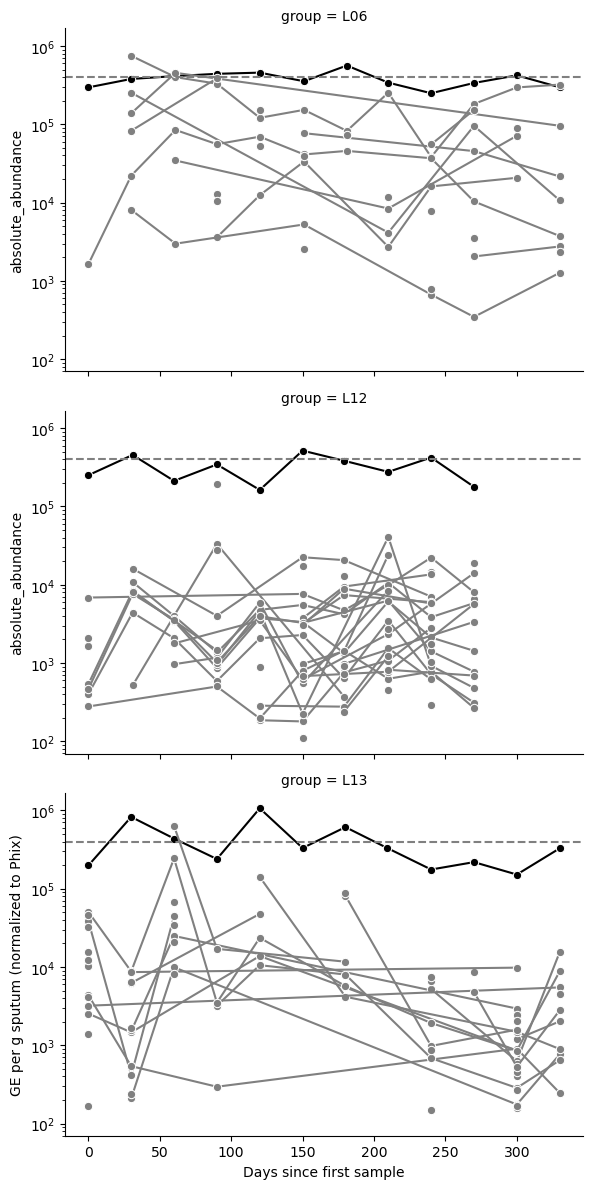

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
# prepare data for plotting
put_viruses = put_viruses.sort('group', descending=False)
g = sns.FacetGrid(put_viruses, row='group', height=4, aspect=1.5)

custom_palette = {}
for contig_id in put_viruses['contig_id'].unique().to_list():
    if contig_id == 'SAMN26351618.contig00026':
        custom_palette[contig_id] = 'black'
    else:
        custom_palette[contig_id] = 'grey'


# custom_palette
g.map_dataframe(sns.lineplot, x='day', y='absolute_abundance', hue='contig_id', palette=custom_palette, marker='o', legend=False)
g.map(lambda *args, **kwargs: plt.axhline(y=4E5, color="grey", linestyle="--"))

plt.yscale('log')
plt.ylabel('GE per g sputum (normalized to Phix)')
plt.xlabel('Days since first sample')
plt.legend().remove()
plt.show()

/tmp/ipykernel_2153/4203326568.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


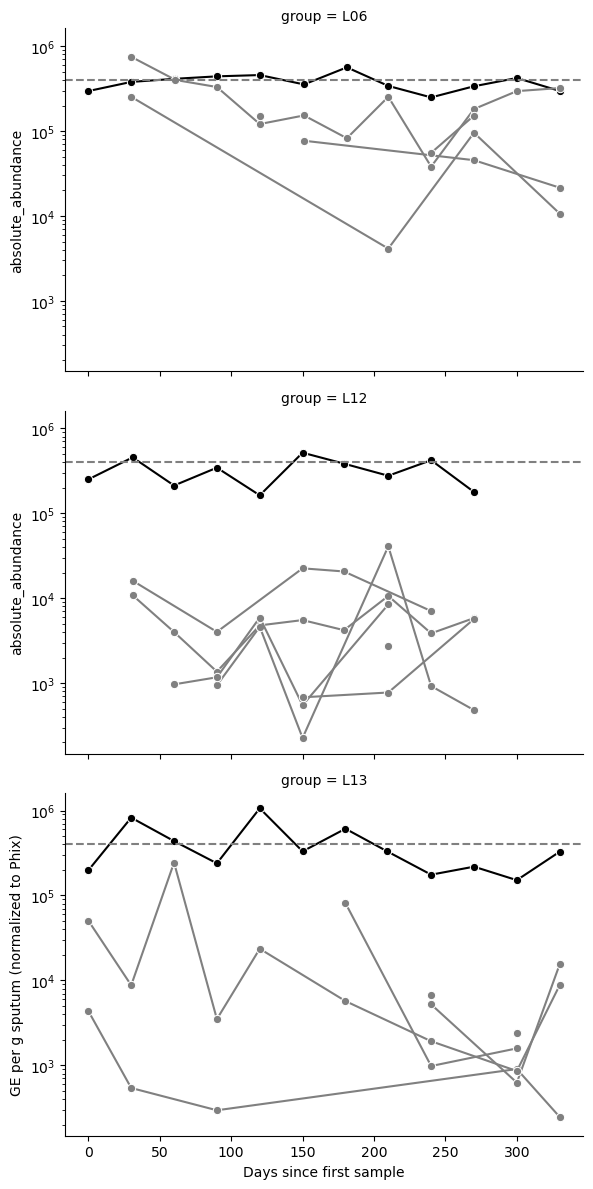

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
# prepare data for plotting
active_viruses = active_viruses.sort('group', descending=False)
g = sns.FacetGrid(active_viruses, row='group', height=4, aspect=1.5)

custom_palette = {}
for contig_id in active_viruses['contig_id'].unique().to_list():
    if contig_id == 'SAMN26351618.contig00026':
        custom_palette[contig_id] = 'black'
    else:
        custom_palette[contig_id] = 'grey'
# custom_palette
g.map_dataframe(sns.lineplot, x='day', y='absolute_abundance', hue='contig_id', palette=custom_palette, marker='o', legend=False)
g.map(lambda *args, **kwargs: plt.axhline(y=4E5, color="grey", linestyle="--"))

plt.yscale('log')
plt.ylabel('GE per g sputum (normalized to Phix)')
plt.xlabel('Days since first sample')
plt.legend().remove()
plt.show()